# 11 — EDA de producción, clima y proyecciones propias

**Entradas:** las dos salidas de 10. Este notebook es descriptivo: cobertura, calidad, composición, error de la teoría, persistencia productiva, clima y revisiones de pronósticos. No selecciona variables ni parámetros usando los bloques de evaluación. Las asociaciones exploratorias principales se calculan antes del primer corte del modelo (2025-07-07).

Una fila del panel semanal equivale a una serie/semana real; una fila de casos equivale a serie/origen/horizonte. Se usan por separado para no sumar varias veces la misma producción. El error se define `real − teoría`: positivo significa subestimación. WAPE no es porcentaje de aciertos; se informa siempre población y cobertura.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').is_dir())
SALIDA=ROOT/'Datos_analiticos_proyecto'
DESTINO=SALIDA/'modelo_con_proyecciones_teoricas'
DESTINO.mkdir(exist_ok=True)
KEY=['finca','producto','color','variedad']
SEM=KEY+['semana_inicio']
pd.set_option('display.max_columns',30)

base=pd.read_parquet(DESTINO/'produccion_clima_semanal.parquet')
casos=pd.read_parquet(DESTINO/'base_analitica_proyecciones.parquet')
assert not base.duplicated(SEM).any()
assert not casos.duplicated(KEY+['origen','horizonte']).any()
print('Panel semanal:',base.shape,'; casos:',casos.shape)


Panel semanal: (44053, 20) ; casos: (621195, 47)


## 1. Calidad, calendario, ceros y cobertura

In [2]:
display(base.groupby(base.semana_inicio.dt.year).agg(semanas=('semana_inicio','nunique'),series=('variedad','nunique'),tallos=('tallos_reales','sum')))
display(base[['tallos_reales','temperatura_semana','humedad_semana','radiacion_semana','dias_clima']].describe(percentiles=[.01,.1,.5,.9,.99]).T)
display(casos.groupby('motivo_cobertura').agg(casos=('origen','size'),targets_observados=('y','count')))
observados=casos.loc[casos.y.notna()].copy()
cobertura=observados.groupby([observados.origen.dt.year,'horizonte']).agg(casos=('y','size'),con_teoria=('curva_completa','sum'),admisibles=('admisible_modelo','sum'))
cobertura['cobertura_teoria_pct']=100*cobertura.con_teoria/cobertura.casos
display(cobertura)
display(casos[['y','teoria_modelo','media_4','temperatura_semana_lag1','teoria_previa_1','teoria_previa_2']].isna().mean().mul(100).to_frame('faltantes_pct'))
print('Semanas reportadas con cero:',int(base.tallos_reales.eq(0).sum()),'; cantidades negativas:',int(base.tallos_reales.lt(0).sum()))
print('Targets sin reporte:',int(casos.y.isna().sum()),'(incluye objetivos futuros; no equivale a cero).')


,semanas,series,tallos
semana_inicio,,,
2021,52,209,53374645
2022,51,277,48704873
2023,52,279,57341913
2024,53,251,59678405
2025,52,262,61271539
2026,35,231,47619825


,count,mean,std,min,1%,10%,50%,90%,99%,max
tallos_reales,44053.0,7445.377159,11622.91821,1.0,6.0,52.0,3130.0,21076.4,55843.32,168051.0
temperatura_semana,44053.0,14.217477,0.926335,11.949767,12.24881,13.097386,14.130285,15.287987,16.820238,17.107816
humedad_semana,44053.0,82.7906,4.645859,51.004365,70.429336,77.221142,83.266147,87.907738,91.005952,92.956392
radiacion_semana,44053.0,173.421493,32.061518,104.819831,119.696429,141.168137,168.673895,208.440476,321.64,328.018822
dias_clima,44053.0,6.991351,0.189247,6.0,6.0,7.0,7.0,7.0,7.0,10.0


,casos,targets_observados
motivo_cobertura,,
cohortes_sin_curva,229938,159656
curva_completa,47677,44848
sin_pareja_comercial_u_objetivo,342565,5523
sin_snapshot_disponible,1015,974


casos  con_teoria  admisibles  cobertura_teoria_pct
origen horizonte                                                     
2021   1.0         6375        1126        2343             17.662745
       2.0         6284        1144        2330             18.204965
       3.0         6192        1163        2318               18.7823
       4.0         6103        1201        2305             19.678846
       5.0         6013        1206        2293             20.056544
2022   1.0         7309        1196        4550             16.363388
       2.0         7253        1223        4517             16.861988
       3.0         7178        1249        4477              17.40039
       4.0         7030        1235        4430             17.567568
       5.0         6963        1215        4401             17.449375
2023   1.0         8567        1876        6055             21.897981
       2.0         8463        2015        6004             23.809524
       3.0         8361        2072        5947             24.781725
       4.0         8325        2049        5911             24.612613
       5.0         8223        2009        5860             24.431473
2024   1.0         7402        2697        6125             36.436098
       2.0         7324        2721        6084              37.15183
       3.0         7251        2714        6040              37.42932
       4.0         7190        2705        5998             37.621697
       5.0         7127        2630        5957             36.901922
2025   1.0         7982        1547        6234             19.381107
       2.0         7932        1523        6194             19.200706
       3.0         7880        1493        6157             18.946701
       4.0         7823        1490        6115             19.046402
       5.0         7761        1533        6078             19.752609
2026   1.0         5755         408        4139              7.089487
       2.0         5544         381        3981              6.872294
       3.0         5334         356        3835              6.674166
       4.0         5127         339        3684              6.612054
       5.0         4930         332        3535               6.73428

,faltantes_pct
y,66.033049
teoria_modelo,92.324954
media_4,68.428593
temperatura_semana_lag1,0.198810
teoria_previa_1,92.360209
teoria_previa_2,92.417196


Semanas reportadas con cero: 0 ; cantidades negativas: 0
Targets sin reporte: 410194 (incluye objetivos futuros; no equivale a cero).


## 2. Composición y evolución temporal

Los totales de esta sección provienen exclusivamente del panel semanal.

,tallos,series,semanas,participacion_pct
producto,,,,
MINICARNATION,206209767,178,295,62.870518
CARNATION,60581236,278,295,18.470385
SOLOMIO,26501450,54,295,8.079927
RAFFINE,18399760,21,294,5.609833
GREEN BALL,5839878,9,295,1.780498
STAR,4261749,2,291,1.299349
BARBATUS,2193346,43,270,0.668721
VERONICA,1686990,7,272,0.51434
VERONICA SPRAY,706463,3,126,0.215391


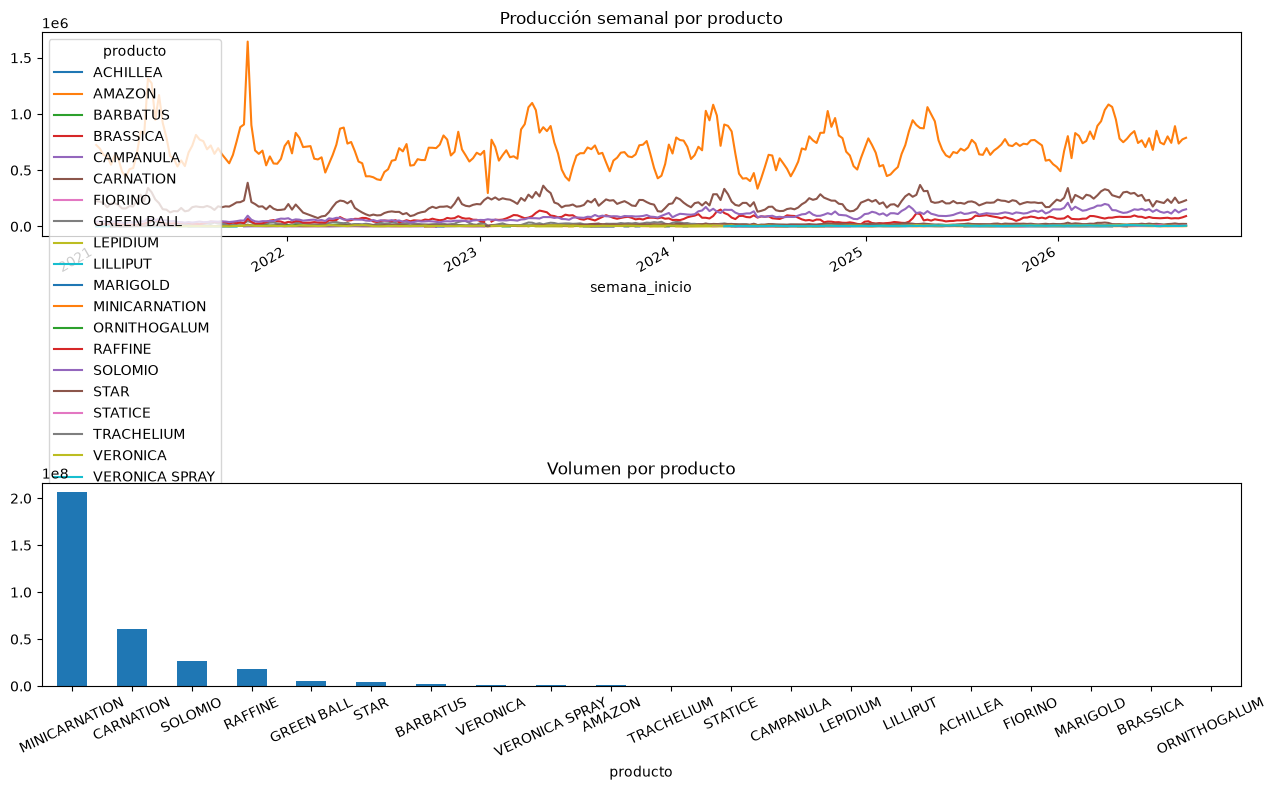

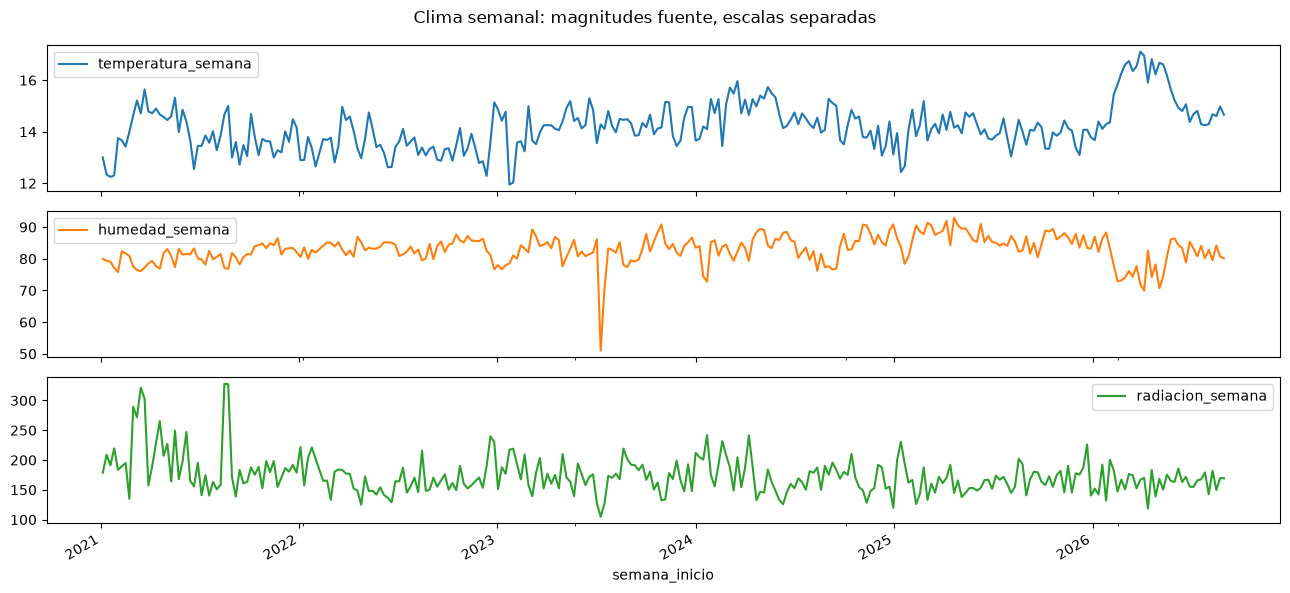

In [3]:
composicion=base.groupby('producto').agg(tallos=('tallos_reales','sum'),series=('variedad','nunique'),semanas=('semana_inicio','nunique')).sort_values('tallos',ascending=False)
composicion['participacion_pct']=100*composicion.tallos/composicion.tallos.sum()
display(composicion)
fig,ax=plt.subplots(2,1,figsize=(13,8))
base.groupby(['semana_inicio','producto']).tallos_reales.sum().unstack().plot(ax=ax[0],title='Producción semanal por producto')
composicion.tallos.plot.bar(ax=ax[1],title='Volumen por producto',rot=25)
fig.tight_layout();plt.show()
clima=base.groupby('semana_inicio')[['temperatura_semana','humedad_semana','radiacion_semana']].first()
clima.plot(subplots=True,figsize=(13,6),title='Clima semanal: magnitudes fuente, escalas separadas')
plt.tight_layout();plt.show()


## 3. Error de la teoría: horizonte, periodo y dimensiones

Se excluyen proyecciones parciales. Se muestran los cinco horizontes por separado y no se afirma que cubran las mismas series. El resumen por origen suma sólo la población emparejada, no toda la finca.

,n,real,MAE,WAPE,sesgo,ceros_reales
horizonte,,,,,,
1.0,8850.0,77915798.0,3781.877213,0.429561,-2665.923938,0.0
2.0,9007.0,80630563.0,3786.383967,0.422966,-2653.061453,0.0
3.0,9047.0,81585717.0,3721.885576,0.412718,-2571.031131,0.0
4.0,9019.0,81683796.0,3705.080768,0.409091,-2551.480291,0.0
5.0,8925.0,82027856.0,3700.148893,0.402593,-2516.735313,0.0


n        real          MAE      WAPE        sesgo  \
origen horizonte                                                           
2021   1.0        1126.0   8532870.0  2259.170663  0.298121  -605.611996   
       2.0        1144.0   8659495.0  2280.497243  0.301275  -636.221733   
       3.0        1163.0   8715371.0  2408.710258  0.321424  -711.044845   
       4.0        1201.0   9095792.0  2586.637132  0.341537  -871.925468   
       5.0        1206.0   9463046.0  2704.058620  0.344614  -945.520658   
2022   1.0        1196.0  11580886.0  2517.387924  0.259980 -1231.209068   
       2.0        1223.0  11829555.0  2608.632656  0.269694 -1333.988880   
       3.0        1249.0  11896139.0  2605.019542  0.273506 -1346.437358   
       4.0        1235.0  11644999.0  2619.113512  0.277768 -1377.708473   
       5.0        1215.0  11581364.0  2644.639482  0.277449 -1466.037129   
2023   1.0        1876.0  13170160.0  2746.346008  0.391198 -1554.110369   
       2.0        2015.0  14467570.0  2815.414192  0.392122 -1651.607264   
       3.0        2072.0  15150580.0  2758.939091  0.377314 -1587.395238   
       4.0        2049.0  15227422.0  2780.295302  0.374116 -1648.453739   
       5.0        2009.0  15408322.0  2891.982657  0.377069 -1729.646818   
2024   1.0        2697.0  28921682.0  5756.816904  0.536834 -4843.856749   
       2.0        2721.0  30123193.0  5773.299288  0.521497 -4842.422509   
       3.0        2714.0  30205076.0  5701.104637  0.512258 -4798.229572   
       4.0        2705.0  30256131.0  5675.442097  0.507404 -4767.188018   
       5.0        2630.0  29742757.0  5633.673482  0.498157 -4693.418077   
2025   1.0        1547.0  12785900.0  4071.241807  0.492590 -3202.843574   
       2.0        1523.0  12619093.0  3989.755482  0.481524 -3015.158144   
       3.0        1493.0  12625724.0  3774.802492  0.446373 -2701.419107   
       4.0        1490.0  12457718.0  3513.488766  0.420229 -2396.860025   
       5.0        1533.0  12634045.0  3343.733328  0.405725 -2168.245907   
2026   1.0         408.0   2924300.0  2300.244689  0.320931 -1237.230362   
       2.0         381.0   2931657.0  2220.759185  0.288611 -1156.200287   
       3.0         356.0   2992827.0  2224.155803  0.264566 -1142.630640   
       4.0         339.0   3001734.0  2333.253275  0.263505 -1235.697793   
       5.0         332.0   3198322.0  2400.601187  0.249193 -1198.369487   

                  ceros_reales  
origen horizonte                
2021   1.0                 0.0  
       2.0                 0.0  
       3.0                 0.0  
       4.0                 0.0  
       5.0                 0.0  
2022   1.0                 0.0  
       2.0                 0.0  
       3.0                 0.0  
       4.0                 0.0  
       5.0                 0.0  
2023   1.0                 0.0  
       2.0                 0.0  
       3.0                 0.0  
       4.0                 0.0  
       5.0                 0.0  
2024   1.0                 0.0  
       2.0                 0.0  
       3.0                 0.0  
       4.0                 0.0  
       5.0                 0.0  
2025   1.0                 0.0  
       2.0                 0.0  
       3.0                 0.0  
       4.0                 0.0  
       5.0                 0.0  
2026   1.0                 0.0  
       2.0                 0.0  
       3.0                 0.0  
       4.0                 0.0  
       5.0                 0.0

n        real          MAE      WAPE  \
producto       horizonte                                              
AMAZON         1.0          14.0     47852.0  1086.370060  0.317838   
               2.0          32.0    100848.0   988.964359  0.313808   
               3.0          52.0    151704.0  1064.448105  0.364864   
               4.0          45.0    130318.0  1037.199488  0.358154   
               5.0          36.0    103244.0  1092.462151  0.380929   
BARBATUS       1.0         179.0    265550.0   663.383705  0.447169   
               2.0         174.0    268183.0   631.843408  0.409947   
               3.0         183.0    285085.0   674.068642  0.432694   
               4.0         188.0    299967.0   759.955988  0.476291   
               5.0         194.0    310795.0   744.648134  0.464814   
CARNATION      1.0        4113.0  16657560.0  1920.953751  0.474312   
               2.0        4065.0  16888109.0  1933.911565  0.465496   
               3.0        3981.0  16830943.0  1922.572526  0.454743   
               4.0        3935.0  16990288.0  1899.767809  0.439992   
               5.0        3797.0  16683333.0  1867.886995  0.425117   
GREEN BALL     1.0         204.0   2354522.0  4930.342544  0.427174   
               2.0         188.0   2299945.0  5165.874363  0.422264   
               3.0         190.0   2297678.0  5327.175537  0.440516   
               4.0         195.0   2360445.0  5619.351700  0.464223   
               5.0         218.0   2584388.0  5861.869418  0.494464   
MINICARNATION  1.0        1985.0  38636420.0  9173.595680  0.471306   
               2.0        2027.0  39494882.0  9235.813823  0.474011   
               3.0        2018.0  39352371.0  9035.969458  0.463367   
               4.0        1994.0  39095171.0  9039.194805  0.461033   
               5.0        1979.0  39307744.0  8963.180145  0.451263   
RAFFINE        1.0         754.0   8920632.0  3563.370207  0.301187   
               2.0         766.0   9300002.0  3687.861919  0.303753   
               3.0         799.0   9923376.0  3795.685914  0.305617   
               4.0         794.0   9766130.0  3854.233889  0.313355   
               5.0         801.0   9897930.0  3951.730092  0.319798   
SOLOMIO        1.0        1314.0   9714570.0  2390.609121  0.323356   
               2.0        1423.0  10618347.0  2213.721263  0.296668   
               3.0        1445.0  10860185.0  2134.034772  0.283944   
               4.0        1465.0  11097418.0  2102.301781  0.277531   
               5.0        1453.0  11087794.0  2092.366437  0.274194   
STAR           1.0          75.0    788899.0  2827.818113  0.268838   
               2.0         112.0   1114091.0  2207.297257  0.221900   
               3.0         141.0   1304656.0  1895.880228  0.204896   
               4.0         141.0   1312598.0  1802.652366  0.193642   
               5.0         141.0   1326123.0  1791.549795  0.190486   
TRACHELIUM     1.0          58.0    190617.0  1056.609059  0.321500   
               2.0          58.0    195933.0  1067.008922  0.315856   
               3.0          57.0    195333.0  1061.609553  0.309788   
               4.0          56.0    193884.0  1049.287315  0.303068   
               5.0          57.0    198564.0  1033.377898  0.296643   
VERONICA       1.0         127.0    287985.0   789.041359  0.347963   
               2.0         132.0    291622.0   781.753062  0.353853   
               3.0         140.0    303975.0   829.877870  0.382212   
               4.0         147.0    315175.0   849.696753  0.396305   
               5.0         161.0    344507.0   854.027207  0.399116   
VERONICA SPRAY 1.0          27.0     51191.0   658.478775  0.347306   
               2.0          30.0     58601.0   717.348939  0.367237   
               3.0          41.0     80411.0   786.218191  0.400877   
               4.0          59.0    122402.0   899.831909  0.433735   
               5.0          88.0    183434.0   876.1006

n       real  \
finca   producto      color          variedad     horizonte                     
GAITANA CARNATION     YELLOW         BELLO        2.0         20.0     3724.0   
                      ORANGE         ALHAMBRA     1.0         20.0     8611.0   
                      YELLOW         BELLO        1.0         21.0     4082.0   
                      ORANGE         ARNO         5.0         23.0    14218.0   
        MINICARNATION ORANGE         ROMANY       5.0         24.0    58281.0   
                                                  4.0         25.0    59640.0   
        CARNATION     ORANGE         ARNO         4.0         24.0    15686.0   
        MINICARNATION ORANGE         ROMANY       3.0         26.0    63068.0   
        CARNATION     ORANGE         ARNO         3.0         25.0    17434.0   
        MINICARNATION ORANGE         ROMANY       2.0         28.0    83914.0   
                      BICOLOR YELLOW MAKUMBA      5.0         22.0    10859.0   
        CARNATION     ORANGE         ARNO         2.0         26.0    18903.0   
        MINICARNATION BICOLOR YELLOW MAKUMBA      4.0         23.0    11779.0   
        CARNATION     WHITE          ANTARTIDA    1.0         25.0     1401.0   
                      PEACH          BRUT         1.0         54.0   295158.0   
        MINICARNATION BICOLOR YELLOW MAKUMBA      3.0         24.0    12278.0   
        CARNATION     ORANGE         ARNO         1.0         27.0    20620.0   
        MINICARNATION ORANGE         ROMANY       1.0         30.0   105179.0   
                                     ORANGE LIMBO 5.0         34.0    62276.0   
        CARNATION     HOT PINK       ZEPPELIN     2.0        103.0  1186299.0   
                                                  1.0        104.0  1200826.0   
                      DARK PINK      BUBLICIUS    1.0         38.0    70522.0   
                      WHITE          ANTARTIDA    2.0         24.0     1386.0   
        RAFFINE       HOT PINK       LUCE         5.0         21.0    64880.0   
        MINICARNATION LIGHT PINK     ZAGARA       3.0         50.0  1850996.0   
        CARNATION     WHITE          ANTARTIDA    5.0         21.0     1163.0   
                      PEACH          BRUT         2.0         56.0   305472.0   
                      HOT PINK       ZEPPELIN     3.0        101.0  1175667.0   
                      PEACH          BRUT         3.0         49.0   272841.0   
        MINICARNATION LIGHT PINK     ZAGARA       2.0         49.0  1838273.0   

                                                                      MAE  \
finca   producto      color          variedad     horizonte                 
GAITANA CARNATION     YELLOW         BELLO        2.0          461.329785   
                      ORANGE         ALHAMBRA     1.0         1048.479362   
                      YELLOW         BELLO        1.0          445.157669   
                      ORANGE         ARNO         5.0         1100.544933   
        MINICARNATION ORANGE         ROMANY       5.0         4142.903709   
                                                  4.0         3982.964392   
        CARNATION     ORANGE         ARNO         4.0         1010.538430   
        MINICARNATION ORANGE         ROMANY       3.0         3714.918019   
        CARNATION     ORANGE         ARNO         3.0          878.088677   
        MINICARNATION ORANGE         ROMANY       2.0         3373.434077   
                      BICOLOR YELLOW MAKUMBA      5.0          544.734046   
        CARNATION     ORANGE         ARNO         2.0          794.896429   
        MINICARNATION BICOLOR YELLOW MAKUMBA      4.0          525.705619   
        CARNATION     WHITE          ANTARTIDA    1.0           57.398400   
                      PEACH          BRUT         1.0         5208.381585   
        MINICARNATION BICOLOR YELLOW MAKUMBA      3.0          481.207404   
        CARNATION     ORANGE         ARNO         1.0          707.740587   
        M

n        real           MAE      WAPE  \
producto      color                                                          
MINICARNATION YELLOW             693.0  32906091.0  19414.700232  0.408872   
RAFFINE       BICOLOR BURGUNDY  1147.0  21268571.0   5480.748405  0.295573   
MINICARNATION LIGHT PINK         882.0  19293288.0  13012.174424  0.594857   
              WHITE              990.0  18705450.0  10539.855347  0.557830   
              RED                536.0  16558950.0  18557.303395  0.600685   
              BICOLOR RED       1272.0  15363832.0   3922.255848  0.324731   
              HOT PINK           408.0  15013200.0  13767.974075  0.374160   
              LAVENDER           585.0  12776697.0   8559.571015  0.391913   
CARNATION     WHITE             2318.0  12613484.0   2182.016432  0.400993   
GREEN BALL    GREEN              995.0  11896978.0   5389.747463  0.450770   
SOLOMIO       HOT PINK           936.0  11274870.0   3381.537911  0.280723   
RAFFINE       LIGHT PINK         932.0  11100667.0   3575.963465  0.300234   
MINICARNATION GREEN              741.0  10774927.0   6046.645552  0.415832   
              BICOLOR PINK       658.0  10086506.0   7050.302681  0.459931   
              PURPLE             380.0   9579783.0  12835.777459  0.509155   
              BURGUNDY           412.0   9059506.0  12014.075032  0.546365   
SOLOMIO       BICOLOR PURPLE    1693.0   8905277.0   1178.384957  0.224025   
MINICARNATION ORANGE             796.0   7955888.0   4599.270231  0.460165   
RAFFINE       BICOLOR PURPLE     939.0   7516742.0   2584.211963  0.322823   
MINICARNATION CREAM              364.0   7464152.0  11520.514633  0.561814   
CARNATION     ORANGE            1755.0   7306246.0   1685.463625  0.404858   
SOLOMIO       WHITE              678.0   6969466.0   5161.579303  0.502126   
CARNATION     RED               1551.0   6795703.0   1432.059770  0.326843   
SOLOMIO       ORANGE             596.0   6730275.0   2362.878796  0.209245   
RAFFINE       WHITE              568.0   6633551.0   3573.799922  0.306008   
CARNATION     HOT PINK           772.0   6425588.0   6724.290551  0.807888   
              BICOLOR YELLOW    1421.0   6340518.0   1738.746958  0.389678   
              PURPLE            1646.0   5973125.0   1378.731806  0.379934   
SOLOMIO       LIGHT PINK        1337.0   5903329.0   1248.415913  0.282744   
CARNATION     YELLOW             827.0   5627925.0   3605.041803  0.529746   

                                       sesgo  ceros_reales  
producto      color                                         
MINICARNATION YELLOW           -17491.487796           0.0  
RAFFINE       BICOLOR BURGUNDY    573.101084           0.0  
MINICARNATION LIGHT PINK       -12209.773645           0.0  
              WHITE             -9550.926763           0.0  
              RED              -16547.477889           0.0  
              BICOLOR RED       -3083.249269           0.0  
              HOT PINK         -12431.542658           0.0  
              LAVENDER          -6020.177519           0.0  
CARNATION     WHITE             -1312.717076           0.0  
GREEN BALL    GREEN             -2887.944787           0.0  
SOLOMIO       HOT PINK          -2441.334712           0.0  
RAFFINE       LIGHT PINK         1377.286014           0.0  
MINICARNATION GREEN             -4392.092533           0.0  
              BICOLOR PINK      -5854.259805           0.0  
              PURPLE           -11942.168834           0.0  
              BURGUNDY         -10613.638940           0.0  
SOLOMIO       BICOLOR PURPLE     -679.254368           0.0  
MINICARNATION ORANGE            -2882.863419           0.0  
RAFFINE       BICOLOR PURPLE     -528.657296           0.0  
MINICARNATION CREAM            -11212.281624           0.0  
CARNATION     ORANGE            -1159.368211           0.0  
SOLOMIO       WHITE             -4480.106276           0.0  
CARNATION     RED                -805.320965           0.0  
SOLOMIO       O

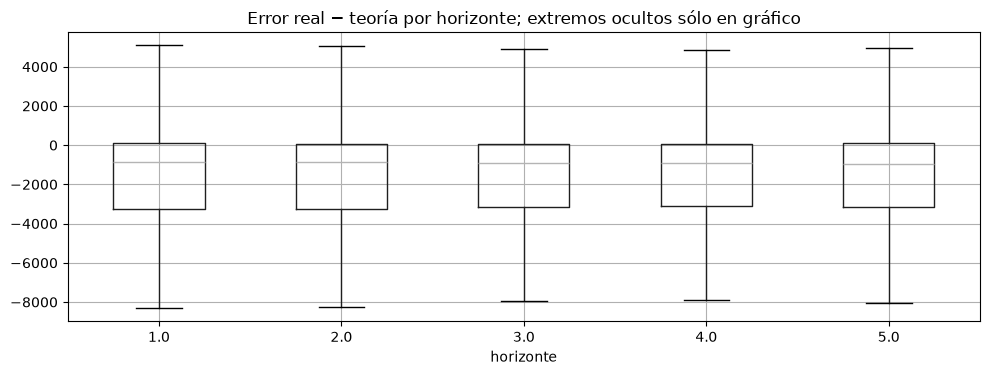

In [4]:
pares=observados.loc[observados.curva_completa].copy()
pares['error']=pares.y-pares.teoria_modelo
pares['absoluto']=pares.error.abs()
def metricas(g):
    return pd.Series({'n':len(g),'real':g.y.sum(),'MAE':g.absoluto.mean(),'WAPE':g.absoluto.sum()/g.y.sum() if g.y.sum()>0 else np.nan,'sesgo':g.error.mean(),'ceros_reales':g.y.eq(0).sum()})
display(pares.groupby('horizonte').apply(metricas))
display(pares.groupby([pares.origen.dt.year,'horizonte']).apply(metricas))
display(pares.groupby(['producto','horizonte']).apply(metricas))
por_serie=pares.groupby(KEY+['horizonte']).apply(metricas)
display(por_serie.loc[por_serie.n.ge(20)].sort_values('WAPE',ascending=False).head(30))
display(pares.groupby(['producto','color']).apply(metricas).sort_values('real',ascending=False).head(30))
pares.boxplot(column='error',by='horizonte',showfliers=False,figsize=(10,4));plt.suptitle('');plt.title('Error real − teoría por horizonte; extremos ocultos sólo en gráfico');plt.tight_layout();plt.show()


## 4. Memoria productiva, clima y revisiones previas

Spearman dentro de cada serie y horizonte, con al menos 20 pares. Se resume la distribución de correlaciones entre series para evitar que diferencias de tamaño dominen una correlación global. Esto mide asociación, no causalidad; su utilidad predictiva se contrasta por ablación en 12.

In [5]:
explora=pares.loc[(pares.semana_objetivo+pd.Timedelta(days=7)).le(pd.Timestamp('2025-07-07'))].copy()
variables=['produccion_lag1','media_4','cambio_reciente','temperatura_semana_lag1','humedad_semana_lag1','radiacion_semana_lag1','teoria_previa_1','revision_teoria']
correlaciones=[]
for clave,g in explora.groupby(KEY+['horizonte']):
    for variable in variables:
        d=g[[variable,'error']].dropna()
        if len(d)>=20 and d[variable].nunique()>1 and d.error.nunique()>1:
            correlaciones.append({'horizonte':clave[-1],'variable':variable,'n':len(d),'rho':d[variable].corr(d.error,method='spearman')})
correlaciones=pd.DataFrame(correlaciones)
display(correlaciones.groupby(['horizonte','variable']).agg(series=('rho','size'),mediana_rho=('rho','median'),q25=('rho',lambda s:s.quantile(.25)),q75=('rho',lambda s:s.quantile(.75))))
revisiones=explora.dropna(subset=['revision_teoria'])
display(revisiones.groupby('horizonte').agg(casos=('revision_teoria','size'),revision_mediana=('revision_teoria','median'),revision_absoluta_mediana=('revision_teoria',lambda s:s.abs().median())))
print('Cobertura de historia entre pares completos:',round(100*pares.teoria_previa_1.notna().mean(),2),'%')


series  mediana_rho       q25       q75
horizonte variable                                                        
1.0       cambio_reciente             116     0.203639  0.100608  0.309877
          humedad_semana_lag1         117    -0.047387 -0.189840  0.107634
          media_4                     116     0.134960 -0.078401  0.331284
          produccion_lag1             117     0.283869  0.065701  0.476155
          radiacion_semana_lag1       117     0.049321 -0.076979  0.134187
          revision_teoria             111    -0.049507 -0.184620  0.144285
          temperatura_semana_lag1     117     0.002108 -0.146319  0.157560
          teoria_previa_1             113    -0.349908 -0.524110 -0.088817
2.0       cambio_reciente             114     0.199538  0.120775  0.308217
          humedad_semana_lag1         115    -0.075417 -0.226347  0.093589
          media_4                     114     0.068429 -0.118086  0.224444
          produccion_lag1             115     0.188069 -0.030900  0.367297
          radiacion_semana_lag1       115     0.029015 -0.073176  0.151203
          revision_teoria             109    -0.059978 -0.184417  0.043986
          temperatura_semana_lag1     115    -0.043449 -0.147197  0.137473
          teoria_previa_1             111    -0.335385 -0.506218 -0.075160
3.0       cambio_reciente             111     0.123823  0.033200  0.225084
          humedad_semana_lag1         113    -0.080493 -0.252116  0.063092
          media_4                     109    -0.016727 -0.164976  0.170787
          produccion_lag1             111     0.061734 -0.086109  0.240936
          radiacion_semana_lag1       113     0.036561 -0.076411  0.144355
          revision_teoria             106    -0.040621 -0.141541  0.093152
          temperatura_semana_lag1     113    -0.056126 -0.188702  0.087218
          teoria_previa_1             108    -0.331335 -0.512785 -0.055196
4.0       cambio_reciente             109     0.070187 -0.010735  0.169744
          humedad_semana_lag1         111    -0.104855 -0.326787  0.047351
          media_4                     107    -0.035373 -0.202113  0.166226
          produccion_lag1             109    -0.002628 -0.141602  0.182920
          radiacion_semana_lag1       111     0.070228 -0.026327  0.188689
          revision_teoria             107    -0.023664 -0.179705  0.078406
          temperatura_semana_lag1     111    -0.069515 -0.198052  0.173601
          teoria_previa_1             109    -0.331304 -0.505177 -0.066233
5.0       cambio_reciente             110     0.061694 -0.023387  0.147030
          humedad_semana_lag1         113    -0.155439 -0.324460 -0.005257
          media_4                     109    -0.038431 -0.278476  0.158365
          produccion_lag1             111    -0.027766 -0.194390  0.175848
          radiacion_semana_lag1       113     0.068498 -0.032007  0.200786
          revision_teoria             104    -0.052593 -0.158099  0.118278
          temperatura_semana_lag1     113    -0.053967 -0.220209  0.165811
          teoria_previa_1             107    -0.332578 -0.520629 -0.094034

,casos,revision_mediana,revision_absoluta_mediana
horizonte,,,
1.0,7379,0.0,71.902848
2.0,7510,0.0,65.666170
3.0,7521,0.0,70.418421
4.0,7442,0.0,67.634780
5.0,7226,0.0,67.079488


Cobertura de historia entre pares completos: 93.55 %


## 5. Lectura del diagnóstico y paso al modelo

In [6]:
print('La teoría completa cubre',round(100*observados.curva_completa.mean(),2),'% de casos con producción observada.')
print('Variedades sin proyección completa:',observados.loc[~observados.curva_completa,'variedad'].nunique())
display(observados.loc[~observados.curva_completa].groupby(['producto','variedad','motivo_cobertura']).size().rename('casos').reset_index().sort_values('casos',ascending=False).head(40))
print('Los detalles completos permanecen en la base. Las listas de variedades sin curva de origen están en ambos notebooks de proyecciones.')
print('El modelo evaluará ajuste de teoría, clima y revisiones sobre casos comunes; los faltantes activan respaldo explícito, no ceros inventados.')


La teoría completa cubre 21.25 % de casos con producción observada.
Variedades sin proyección completa: 608


,producto,variedad,motivo_cobertura,casos
611,MINICARNATION,LORENZO,cohortes_sin_curva,1408
719,MINICARNATION,UCHUVA,cohortes_sin_curva,1406
714,MINICARNATION,TUNE,cohortes_sin_curva,1402
286,CARNATION,LEGE PINK,cohortes_sin_curva,1380
503,MINICARNATION,ARAGON,cohortes_sin_curva,1247
732,MINICARNATION,ZAGARA,cohortes_sin_curva,1214
107,CARNATION,APPLE TEA,cohortes_sin_curva,1211
544,MINICARNATION,CREME INTERMEZZO,cohortes_sin_curva,1191
408,CARNATION,SPRITZ BIANCO ROSA,cohortes_sin_curva,1165
11,BARBATUS,AMRAS,cohortes_sin_curva,1162


Los detalles completos permanecen en la base. Las listas de variedades sin curva de origen están en ambos notebooks de proyecciones.
El modelo evaluará ajuste de teoría, clima y revisiones sobre casos comunes; los faltantes activan respaldo explícito, no ceros inventados.
